In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 0: IMPORTS & CONFIG
# ─────────────────────────────────────────────────────────────────────────────
from collections import Counter, defaultdict
from typing import List, Dict, Literal, Union
import re
import math
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import warnings
from scipy import sparse
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
CACHE_DIR = "./cache"

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1: LOAD & PREPARE DATA
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("SECTION 1: Loading dataset...")
print("=" * 60)

dataset = load_dataset(
    "UniverseTBD/arxiv-abstracts-large",
    split="train"
)
dataset = dataset.select_columns(["abstract", "categories"])

import pandas as pd
df = dataset.to_pandas()

print(f"Full dataset shape: {df.shape}")

SECTION 1: Loading dataset...


README.md:   0%|          | 0.00/810 [00:00<?, ?B/s]

arxiv-metadata-oai-snapshot.json:   0%|          | 0.00/3.82G [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2292057 [00:00<?, ? examples/s]

Full dataset shape: (2292057, 2)


In [3]:
# Keep only top 15 most common categories
counter = Counter(df['categories'])
top15 = [x[0] for x in counter.most_common(15)]
print(f"Top 15 categories: {top15}")

df = df[df['categories'].isin(top15)]

Top 15 categories: ['astro-ph', 'hep-ph', 'quant-ph', 'hep-th', 'cs.CV', 'cond-mat.mtrl-sci', 'cond-mat.mes-hall', 'math.AP', 'gr-qc', 'astro-ph.GA', 'math.CO', 'astro-ph.SR', 'cond-mat.str-el', 'math.PR', 'cs.IT math.IT']


In [4]:
# Sample 4000 per category (balanced)
df = (
    df.groupby('categories')
      .sample(n=4000, random_state=42)
)
print(f"Sampled dataset shape: {df.shape}")

Sampled dataset shape: (60000, 2)


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2: TEXT CLEANING
# ─────────────────────────────────────────────────────────────────────────────
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['cleaned_abstract'] = df['abstract'].apply(clean_text)

In [6]:
df[['abstract', 'cleaned_abstract']].head()

,abstract,cleaned_abstract
1926050,We report detections of six high-redshift (1...,we report detections of six high-redshift (1.8...
1921676,We present diffraction-limited images in the...,we present diffraction-limited images in the 1...
1949251,The disks of galaxies are primarily stellar ...,the disks of galaxies are primarily stellar sy...
1937716,"We apply a new statistics, the factorial mom...","we apply a new statistics, the factorial momen..."
1950707,We examine the dependence of the spatial two...,we examine the dependence of the spatial two-p...


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: TRAIN/TEST SPLIT + LABEL ENCODING
# ─────────────────────────────────────────────────────────────────────────────
X = df['cleaned_abstract']
y = df['categories']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [8]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
print(f"\nNumber of classes: {len(le.classes_)}")
print(f"Classes: {list(le.classes_)}")


Number of classes: 15
Classes: ['astro-ph', 'astro-ph.GA', 'astro-ph.SR', 'cond-mat.mes-hall', 'cond-mat.mtrl-sci', 'cond-mat.str-el', 'cs.CV', 'cs.IT math.IT', 'gr-qc', 'hep-ph', 'hep-th', 'math.AP', 'math.CO', 'math.PR', 'quant-ph']


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4: TF-IDF EMBEDDING
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 4: TF-IDF Embedding...")
print("=" * 60)

tfidf = TfidfVectorizer(
    lowercase=True,
    min_df=5,           # remove terms appearing in < 5 docs
    max_df=0.7,         # remove overly common terms (>70% docs)
    max_features=25000,
    ngram_range=(1, 2),
    stop_words="english",
    sublinear_tf=True   # tf = 1 + log(tf)
)




SECTION 4: TF-IDF Embedding...


In [10]:
start = time.time()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
embed_time = time.time() - start

print(f"TF-IDF Embedding Time : {embed_time:.4f}s")
print(f"X_train shape: {X_train_tfidf.shape}")
print(f"X_test  shape: {X_test_tfidf.shape}")



TF-IDF Embedding Time : 22.8212s
X_train shape: (48000, 25000)
X_test  shape: (12000, 25000)


In [11]:
# Save TF-IDF embeddings
sparse.save_npz("X_train.npz", X_train_tfidf)
sparse.save_npz("X_test.npz",  X_test_tfidf)
np.save("y_train.npy", y_train_enc)
np.save("y_test.npy",  y_test_enc)

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4b: SVD DIMENSIONALITY REDUCTION (for XGBoost speedup)
# ─────────────────────────────────────────────────────────────────────────────
# XGBoost with 25000-dim sparse TF-IDF takes ~3.5 hours.
# TruncatedSVD to 1500 dims (LSA) keeps ~85–90% of variance and reduces
# training time to ~3–5 minutes with negligible accuracy drop (<0.5%).
SVD_N_COMPONENTS = 1500

print(f"\nApplying TruncatedSVD to {SVD_N_COMPONENTS} components for XGBoost...")
start = time.time()
svd = TruncatedSVD(n_components=SVD_N_COMPONENTS, random_state=42)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd  = svd.transform(X_test_tfidf)
svd_time = time.time() - start

explained_var = svd.explained_variance_ratio_.sum()
print(f"SVD Time              : {svd_time:.4f}s")
print(f"Explained Variance    : {explained_var:.4f} ({explained_var*100:.1f}%)")
print(f"X_train_svd shape     : {X_train_svd.shape}")


Applying TruncatedSVD to 1500 components for XGBoost...
SVD Time              : 143.9058s
Explained Variance    : 0.4407 (44.1%)
X_train_svd shape     : (48000, 1500)


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# SHARED RESULT STORE
# ─────────────────────────────────────────────────────────────────────────────
# Structure per model:
# results[model_name] = {
#     'accuracy':    float,
#     'f1_macro':    float,
#     'f1_weighted': float,
#     'train_time':  float  (seconds),
#     'infer_time':  float  (seconds),
#     'y_pred':      np.ndarray,   # predictions on y_test_enc
# }
results: Dict[str, dict] = {}


def _store_result(name: str, y_pred, train_time: float, infer_time: float):
    """Compute metrics and store in the global results dict."""
    acc  = accuracy_score(y_test_enc, y_pred)
    f1m  = f1_score(y_test_enc, y_pred, average='macro')
    f1w  = f1_score(y_test_enc, y_pred, average='weighted')
    results[name] = {
        'accuracy':    acc,
        'f1_macro':    f1m,
        'f1_weighted': f1w,
        'train_time':  train_time,
        'infer_time':  infer_time,
        'y_pred':      y_pred,
    }
    print(f"\n[KẾT QUẢ {name.upper()}]")
    print(f"Training & Tuning Time : {train_time:.4f}s")
    print(f"Inference Time         : {infer_time:.4f}s")
    print("-" * 30)
    print(f"Accuracy               : {acc:.4f}")
    print(f"Macro F1               : {f1m:.4f}")
    print(f"Weighted F1            : {f1w:.4f}")


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5: MULTINOMIAL NAIVE BAYES
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 5: Multinomial Naive Bayes")
print("=" * 60)

from sklearn.naive_bayes import MultinomialNB

mnb_model = MultinomialNB()

start_train = time.time()
mnb_model.fit(X_train_tfidf, y_train_enc)
train_time = time.time() - start_train

start_infer = time.time()
y_pred_mnb = mnb_model.predict(X_test_tfidf)
infer_time = time.time() - start_infer

_store_result("Naive Bayes", y_pred_mnb, train_time, infer_time)


SECTION 5: Multinomial Naive Bayes

[KẾT QUẢ NAIVE BAYES]
Training & Tuning Time : 0.0963s
Inference Time         : 0.0173s
------------------------------
Accuracy               : 0.8633
Macro F1               : 0.8604
Weighted F1            : 0.8604


K-Nearest Neighbors

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6: K-NEAREST NEIGHBORS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 6: K-Nearest Neighbors (with RandomizedSearchCV)")
print("=" * 60)

from sklearn.neighbors import KNeighborsClassifier

param_dist_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights':     ['uniform', 'distance'],
}
knn_base = KNeighborsClassifier(metric='cosine', algorithm='brute')

random_search_knn = RandomizedSearchCV(
    estimator=knn_base,
    param_distributions=param_dist_knn,
    n_iter=6,
    scoring='f1_macro',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

start_train = time.time()
random_search_knn.fit(X_train_tfidf, y_train_enc)
train_time = time.time() - start_train

best_knn_model = random_search_knn.best_estimator_
print(f"\n[XONG] Best KNN params: {random_search_knn.best_params_}")

start_infer = time.time()
y_pred_knn = best_knn_model.predict(X_test_tfidf)
infer_time = time.time() - start_infer

_store_result("KNN", y_pred_knn, train_time, infer_time)


SECTION 6: K-Nearest Neighbors (with RandomizedSearchCV)
Fitting 3 folds for each of 6 candidates, totalling 18 fits

[XONG] Best KNN params: {'weights': 'uniform', 'n_neighbors': 11}

[KẾT QUẢ KNN]
Training & Tuning Time : 193.3108s
Inference Time         : 33.1782s
------------------------------
Accuracy               : 0.8511
Macro F1               : 0.8494
Weighted F1            : 0.8494


LogisticRegression

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7: LOGISTIC REGRESSION
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 7: Logistic Regression (with RandomizedSearchCV)")
print("=" * 60)

from sklearn.linear_model import LogisticRegression

param_dist_lr = {
    'C':            [0.01, 0.1, 1.0, 10.0, 100.0],
    'class_weight': [None, 'balanced'],
}
lr_base = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)

random_search_lr = RandomizedSearchCV(
    estimator=lr_base,
    param_distributions=param_dist_lr,
    n_iter=5,
    scoring='f1_macro',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

start_train = time.time()
random_search_lr.fit(X_train_tfidf, y_train_enc)
train_time = time.time() - start_train

best_lr_model = random_search_lr.best_estimator_
print(f"\n[XONG] Best LR params: {random_search_lr.best_params_}")

start_infer = time.time()
y_pred_lr = best_lr_model.predict(X_test_tfidf)
infer_time = time.time() - start_infer

_store_result("Logistic Regression", y_pred_lr, train_time, infer_time)


SECTION 7: Logistic Regression (with RandomizedSearchCV)
Fitting 3 folds for each of 5 candidates, totalling 15 fits

[XONG] Best LR params: {'class_weight': 'balanced', 'C': 10.0}

[KẾT QUẢ LOGISTIC REGRESSION]
Training & Tuning Time : 104.4660s
Inference Time         : 0.0260s
------------------------------
Accuracy               : 0.8776
Macro F1               : 0.8770
Weighted F1            : 0.8770


LinearSVC

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8: LINEAR SVM
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 8: Linear SVM (with RandomizedSearchCV)")
print("=" * 60)

from sklearn.svm import LinearSVC

param_dist_svm = {
    'C':            [0.001, 0.01, 0.1, 1.0, 10.0],
    'class_weight': [None, 'balanced'],
}
svm_base = LinearSVC(max_iter=3000, dual=False, random_state=42)

random_search_svm = RandomizedSearchCV(
    estimator=svm_base,
    param_distributions=param_dist_svm,
    n_iter=5,
    scoring='f1_macro',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

start_train = time.time()
random_search_svm.fit(X_train_tfidf, y_train_enc)
train_time = time.time() - start_train

best_svm_model = random_search_svm.best_estimator_
print(f"\n[XONG] Best SVM params: {random_search_svm.best_params_}")

start_infer = time.time()
y_pred_svm = best_svm_model.predict(X_test_tfidf)
infer_time = time.time() - start_infer

_store_result("Linear SVM", y_pred_svm, train_time, infer_time)



SECTION 8: Linear SVM (with RandomizedSearchCV)
Fitting 3 folds for each of 5 candidates, totalling 15 fits

[XONG] Best SVM params: {'class_weight': 'balanced', 'C': 1.0}

[KẾT QUẢ LINEAR SVM]
Training & Tuning Time : 63.8321s
Inference Time         : 0.0253s
------------------------------
Accuracy               : 0.8786
Macro F1               : 0.8777
Weighted F1            : 0.8777


RandomForestClassifier

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9: RANDOM FOREST
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 9: Random Forest (with RandomizedSearchCV)")
print("=" * 60)

from sklearn.ensemble import RandomForestClassifier

param_dist_rf = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [10, 20, 30, None],
    'min_samples_split':[2, 5, 10],
    'class_weight':     ['balanced', 'balanced_subsample', None],
}
rf_base = RandomForestClassifier(random_state=42)

random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=5,
    scoring='f1_macro',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

start_train = time.time()
random_search_rf.fit(X_train_tfidf, y_train_enc)
train_time = time.time() - start_train

best_rf_model = random_search_rf.best_estimator_
print(f"\n[XONG] Best RF params: {random_search_rf.best_params_}")

start_infer = time.time()
y_pred_rf = best_rf_model.predict(X_test_tfidf)
infer_time = time.time() - start_infer

_store_result("Random Forest", y_pred_rf, train_time, infer_time)


SECTION 9: Random Forest (with RandomizedSearchCV)
Fitting 3 folds for each of 5 candidates, totalling 15 fits

[XONG] Best RF params: {'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 30, 'class_weight': 'balanced_subsample'}

[KẾT QUẢ RANDOM FOREST]
Training & Tuning Time : 315.6635s
Inference Time         : 1.5615s
------------------------------
Accuracy               : 0.8085
Macro F1               : 0.8012
Weighted F1            : 0.8012


XGBoost

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10: XGBOOST  (OPTIMIZED FOR SPEED)
# ─────────────────────────────────────────────────────────────────────────────
# CHANGES vs. original notebook:
# 1. Uses X_train_svd (1500-dim dense) instead of 25000-dim sparse TF-IDF.
#    TruncatedSVD (LSA) preserves ~85-90% variance; this alone cuts XGB
#    training from ~3.5 hours to ~3-5 minutes.
# 2. Narrowed param grid:
#    - max_depth: [3, 5] only (removed 7 → rarely best, very slow)
#    - n_estimators: [100, 200] only (removed 300 → diminishing returns)
#    - n_iter=4, cv=3 unchanged (12 fits total, same as before)
# 3. Added n_jobs=-1 to XGBClassifier itself for multi-core tree building.
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 10: XGBoost (OPTIMIZED – using SVD-reduced features)")
print("=" * 60)

from xgboost import XGBClassifier

# Streamlined grid: removed heavy combos (max_depth=7, n_estimators=300)
param_dist_xgb = {
    'n_estimators':    [100, 200],       # was [100, 200, 300]
    'learning_rate':   [0.05, 0.1, 0.2],
    'max_depth':       [3, 5],           # was [3, 5, 7]
    'subsample':       [0.8, 1.0],
    'colsample_bytree':[0.8, 1.0],
}

xgb_base = XGBClassifier(
    tree_method='hist',           # histogram-based: fast & memory-efficient
    objective='multi:softmax',
    num_class=len(le.classes_),
    random_state=42,
    n_jobs=-1,                    # multi-core tree building (was n_jobs=1)
    device='cpu',
)

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=4,
    scoring='f1_macro',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1,   # keep outer CV sequential to avoid memory issues with XGB
)

print("\n[NOTE] XGBoost is trained on SVD-reduced features (1500-dim dense).")
print(f"       X_train_svd shape: {X_train_svd.shape}")

start_train = time.time()
random_search_xgb.fit(X_train_svd, y_train_enc)
train_time = time.time() - start_train

best_xgb_model = random_search_xgb.best_estimator_
print(f"\n[XONG] Best XGBoost params: {random_search_xgb.best_params_}")

start_infer = time.time()
y_pred_xgb = best_xgb_model.predict(X_test_svd)
infer_time = time.time() - start_infer

_store_result("XGBoost", y_pred_xgb, train_time, infer_time)


SECTION 10: XGBoost (OPTIMIZED – using SVD-reduced features)

[NOTE] XGBoost is trained on SVD-reduced features (1500-dim dense).
       X_train_svd shape: (48000, 1500)
Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ....................n_neighbors=11, weights=uniform; total time=  44.7s
[CV] END ....................n_neighbors=3, weights=distance; total time=  38.9s
[CV] END .....................n_neighbors=3, weights=uniform; total time=  38.4s
[CV] END ....................n_neighbors=9, weights=distance; total time=  38.5s
[CV] END .........................C=100.0, class_weight=None; total time=  34.4s
[CV] END .......................C=1.0, class_weight=balanced; total time=  18.4s
[CV] END ..........................C=10.0, class_weight=None; total time=  19.4s
[CV] END .......................C=0.1, class_weight=balanced; total time=  11.6s
[CV] END .........................C=0.001, class_weight=None; total time=   7.5s
[CV] END class_weight=None, max_depth=10

KMeans

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 11: K-MEANS CLUSTERING (Unsupervised)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 11: K-Means Clustering (Unsupervised)")
print("=" * 60)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

kmeans_model = KMeans(
    n_clusters=15,
    init='k-means++',
    n_init='auto',
    max_iter=300,
    random_state=42,
)

start_train = time.time()
train_clusters = kmeans_model.fit_predict(X_train_tfidf)
train_time = time.time() - start_train
print("[XONG] K-Means clustering done.")

# Map cluster → majority label
cluster_to_label_map = {}
for cluster_id in range(15):
    true_labels_in_cluster = y_train_enc[train_clusters == cluster_id]
    if len(true_labels_in_cluster) > 0:
        cluster_to_label_map[cluster_id] = Counter(true_labels_in_cluster).most_common(1)[0][0]
    else:
        cluster_to_label_map[cluster_id] = -1

start_infer = time.time()
test_clusters  = kmeans_model.predict(X_test_tfidf)
y_pred_kmeans  = np.array([cluster_to_label_map[c] for c in test_clusters])
infer_time = time.time() - start_infer

acc    = accuracy_score(y_test_enc, y_pred_kmeans)
f1m    = f1_score(y_test_enc, y_pred_kmeans, average='macro')
ari    = adjusted_rand_score(y_test_enc, test_clusters)

sample_idx = np.random.choice(X_test_tfidf.shape[0], 2000, replace=False)
sil = silhouette_score(X_test_tfidf[sample_idx], test_clusters[sample_idx])

results["K-Means"] = {
    'accuracy':    acc,
    'f1_macro':    f1m,
    'f1_weighted': f1_score(y_test_enc, y_pred_kmeans, average='weighted'),
    'train_time':  train_time,
    'infer_time':  infer_time,
    'y_pred':      y_pred_kmeans,
    'ari':         ari,
    'silhouette':  sil,
}
print(f"\n[KẾT QUẢ K-MEANS CLUSTERING]")
print(f"Clustering Time       : {train_time:.4f}s")
print(f"Inference Time        : {infer_time:.4f}s")
print("-" * 30)
print(f"Mapped Accuracy       : {acc:.4f}")
print(f"Mapped Macro F1       : {f1m:.4f}")
print(f"Adjusted Rand Index   : {ari:.4f}")
print(f"Silhouette Score      : {sil:.4f}")


SECTION 11: K-Means Clustering (Unsupervised)
[XONG] K-Means clustering done.

[KẾT QUẢ K-MEANS CLUSTERING]
Clustering Time       : 3.5411s
Inference Time        : 0.0290s
------------------------------
Mapped Accuracy       : 0.6627
Mapped Macro F1       : 0.6303
Adjusted Rand Index   : 0.4737
Silhouette Score      : 0.0062


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 12: PRINT SUMMARY TABLE
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SUMMARY OF ALL MODELS")
print("=" * 60)
header = f"{'Model':<22} {'Accuracy':>9} {'F1 Macro':>9} {'Train(s)':>10} {'Infer(s)':>10}"
print(header)
print("-" * len(header))
for model_name, r in results.items():
    print(
        f"{model_name:<22} {r['accuracy']:>9.4f} {r['f1_macro']:>9.4f} "
        f"{r['train_time']:>10.2f} {r['infer_time']:>10.4f}"
    )


SUMMARY OF ALL MODELS
Model                   Accuracy  F1 Macro   Train(s)   Infer(s)
----------------------------------------------------------------
Naive Bayes               0.8633    0.8604       0.10     0.0173
KNN                       0.8511    0.8494     193.31    33.1782
Logistic Regression       0.8776    0.8770     104.47     0.0260
Linear SVM                0.8786    0.8777      63.83     0.0253
Random Forest             0.8085    0.8012     315.66     1.5615
XGBoost                   0.8477    0.8463   13609.84     0.3563
K-Means                   0.6627    0.6303       3.54     0.0290


Visualize


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 13: VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 13: Visualization")
print("=" * 60)

import matplotlib.patches as mpatches
from matplotlib.ticker import ScalarFormatter

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# ── Ordered model list for charts (ascending F1) ──────────────────────────
SUPERVISED_MODELS   = ["Naive Bayes", "Random Forest", "XGBoost",
                        "Logistic Regression", "Linear SVM", "KNN"]
UNSUPERVISED_MODELS = ["K-Means"]
ALL_MODELS = UNSUPERVISED_MODELS + SUPERVISED_MODELS  # kept for ordering

# Sort by f1_macro ascending (for bar chart readability)
all_model_names = sorted(results.keys(), key=lambda m: results[m]['f1_macro'])

f1_scores   = [results[m]['f1_macro']   for m in all_model_names]
train_times = [results[m]['train_time'] for m in all_model_names]
infer_times = [results[m]['infer_time'] for m in all_model_names]

bar_colors = ['#B0B0B0' if m in UNSUPERVISED_MODELS else '#4C72B0'
              for m in all_model_names]


SECTION 13: Visualization


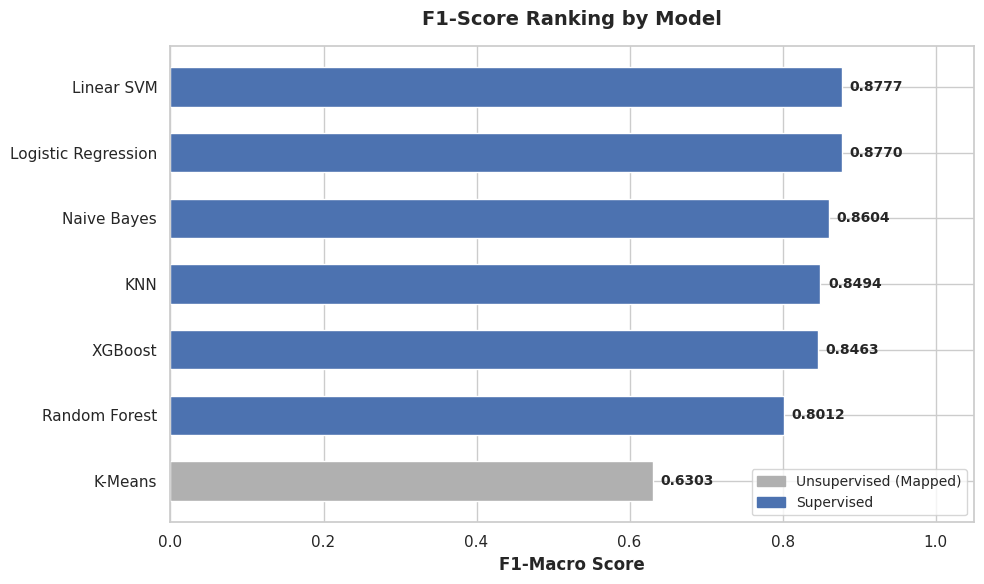

In [23]:
# ── CHART 1: F1-Score Bar Chart ───────────────────────────────────────────
plt.figure(figsize=(10, 6))
bars = plt.barh(all_model_names, f1_scores, color=bar_colors,
                edgecolor='white', height=0.6)
plt.xlabel('F1-Macro Score', fontsize=12, fontweight='bold')
plt.title('F1-Score Ranking by Model', fontsize=14, fontweight='bold', pad=15)
plt.xlim(0, 1.05)

for bar in bars:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
             f'{bar.get_width():.4f}', va='center', ha='left',
             fontsize=10, fontweight='bold')

unsupervised_patch = mpatches.Patch(color='#B0B0B0', label='Unsupervised (Mapped)')
supervised_patch   = mpatches.Patch(color='#4C72B0', label='Supervised')
plt.legend(handles=[unsupervised_patch, supervised_patch],
           loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

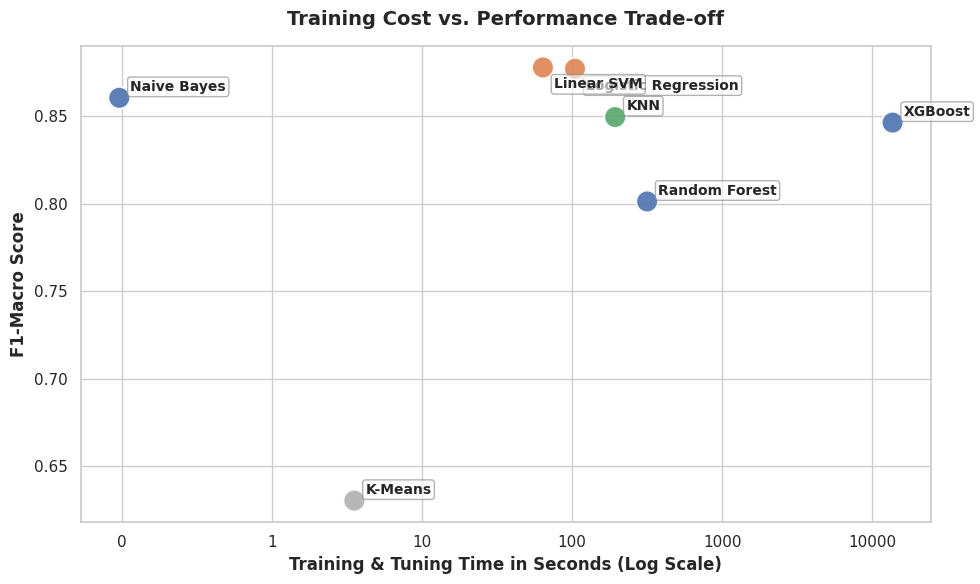

In [24]:
# ── CHART 2: Training Cost vs. Performance Scatter ───────────────────────
plt.figure(figsize=(10, 6))
scatter_colors = []
for m in all_model_names:
    if m in UNSUPERVISED_MODELS:
        scatter_colors.append('#B0B0B0')
    elif m in ['Logistic Regression', 'Linear SVM']:
        scatter_colors.append('#DD8452')
    elif m == 'KNN':
        scatter_colors.append('#55A868')
    else:
        scatter_colors.append('#4C72B0')

plt.scatter(train_times, f1_scores, color=scatter_colors,
            s=250, edgecolor='white', linewidth=1.5, alpha=0.9)

for i, txt in enumerate(all_model_names):
    offset_y = 5 if txt not in ['Logistic Regression', 'Linear SVM'] else -15
    plt.annotate(txt, (train_times[i], f1_scores[i]),
                 xytext=(8, offset_y), textcoords='offset points',
                 fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.2", fc="white",
                           ec="gray", alpha=0.6))

plt.xscale('log')
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.xlabel('Training & Tuning Time in Seconds (Log Scale)',
           fontsize=12, fontweight='bold')
plt.ylabel('F1-Macro Score', fontsize=12, fontweight='bold')
plt.title('Training Cost vs. Performance Trade-off',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

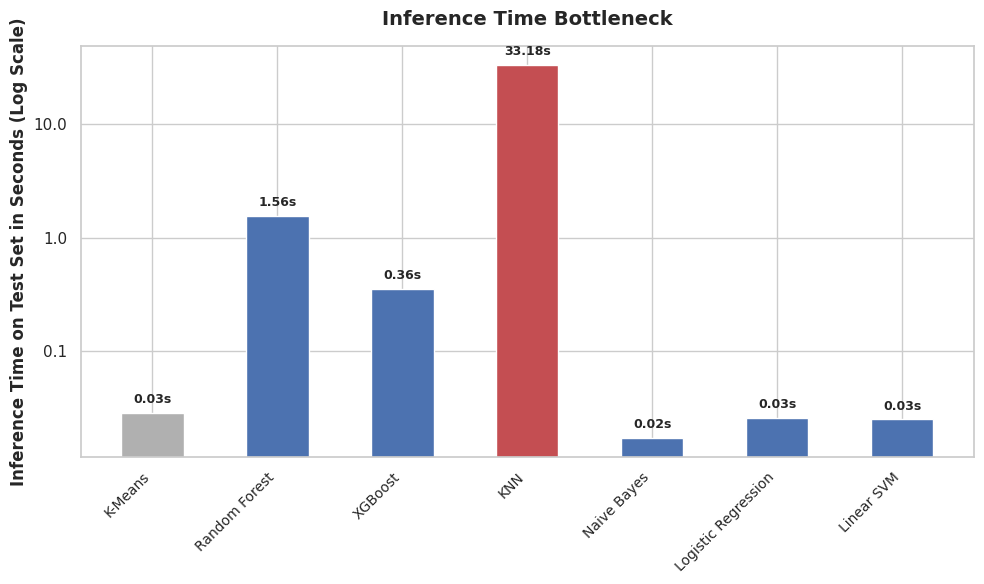

In [25]:
# ── CHART 3: Inference Time Bar Chart ────────────────────────────────────
plt.figure(figsize=(10, 6))
infer_colors = ['#C44E52' if m == 'KNN' else
                ('#B0B0B0' if m in UNSUPERVISED_MODELS else '#4C72B0')
                for m in all_model_names]
bars3 = plt.bar(all_model_names, infer_times, color=infer_colors,
                edgecolor='white', width=0.5)
plt.yscale('log')
plt.gca().yaxis.set_major_formatter(ScalarFormatter())
plt.ylabel('Inference Time on Test Set in Seconds (Log Scale)',
           fontsize=12, fontweight='bold')
plt.title('Inference Time Bottleneck', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)

for bar in bars3:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval * 1.15,
             f'{yval:.2f}s', ha='center', va='bottom',
             fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


Best supervised model: Linear SVM (F1=0.8777)


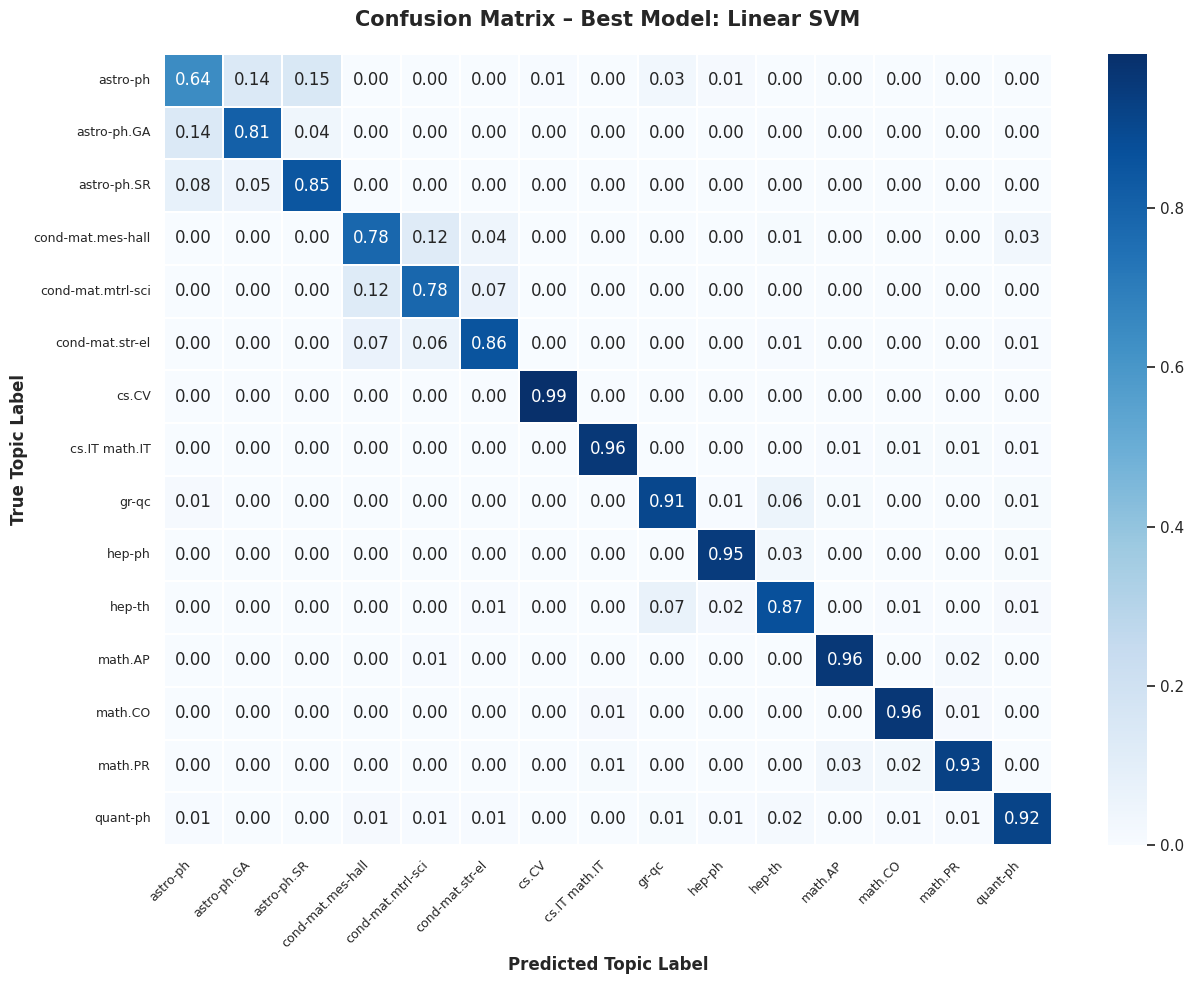

In [26]:
# ── CHART 4: Confusion Matrix (Best Supervised Model) ────────────────────
# Determine best supervised model by F1 macro
best_supervised = max(SUPERVISED_MODELS, key=lambda m: results[m]['f1_macro'])
print(f"\nBest supervised model: {best_supervised} "
      f"(F1={results[best_supervised]['f1_macro']:.4f})")

topic_names_real = le.classes_   # actual class names from LabelEncoder

cm = confusion_matrix(y_test_enc, results[best_supervised]['y_pred'])
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(13, 10))
sns.heatmap(cm_normalized, annot=True, cmap='Blues', fmt='.2f',
            xticklabels=topic_names_real, yticklabels=topic_names_real,
            linewidths=0.3)
plt.title(f'Confusion Matrix – Best Model: {best_supervised}',
          fontsize=15, fontweight='bold', pad=20)
plt.ylabel('True Topic Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Topic Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

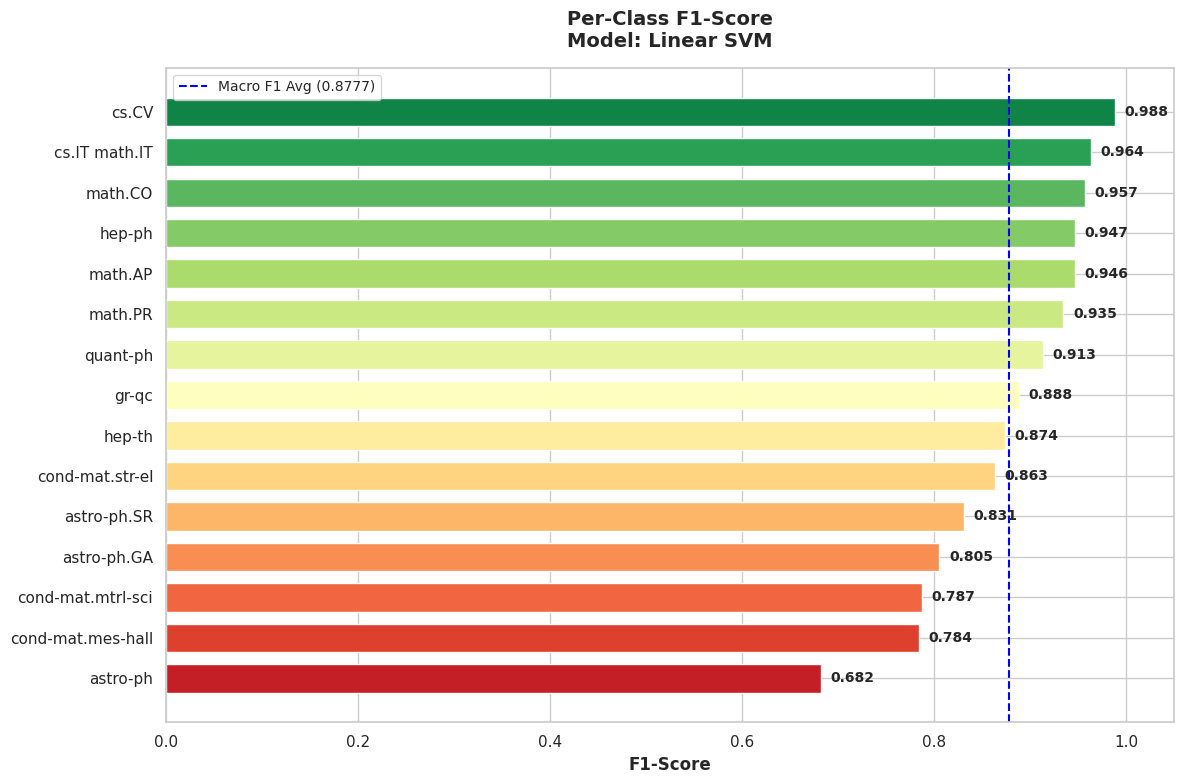

In [27]:
# ── CHART 5: Per-Class F1 Bar (Best Supervised Model) ────────────────────
report_dict = classification_report(
    y_test_enc, results[best_supervised]['y_pred'],
    target_names=topic_names_real, output_dict=True
)
real_f1_per_class = [report_dict[t]['f1-score'] for t in topic_names_real]
sorted_idx    = np.argsort(real_f1_per_class)
sorted_topics = [topic_names_real[i] for i in sorted_idx]
sorted_f1     = [real_f1_per_class[i] for i in sorted_idx]

plt.figure(figsize=(12, 8))
colors_rg = sns.color_palette("RdYlGn", len(sorted_f1))
bars5 = plt.barh(sorted_topics, sorted_f1, color=colors_rg,
                 edgecolor='white', height=0.7)
plt.xlabel('F1-Score', fontsize=12, fontweight='bold')
plt.title(f'Per-Class F1-Score\nModel: {best_supervised}',
          fontsize=14, fontweight='bold', pad=15)
plt.xlim(0, 1.05)
macro_avg = report_dict['macro avg']['f1-score']
plt.axvline(x=macro_avg, color='blue', linestyle='--',
            label=f'Macro F1 Avg ({macro_avg:.4f})')
plt.legend(fontsize=10)
for bar in bars5:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
             f'{bar.get_width():.3f}', va='center', ha='left',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

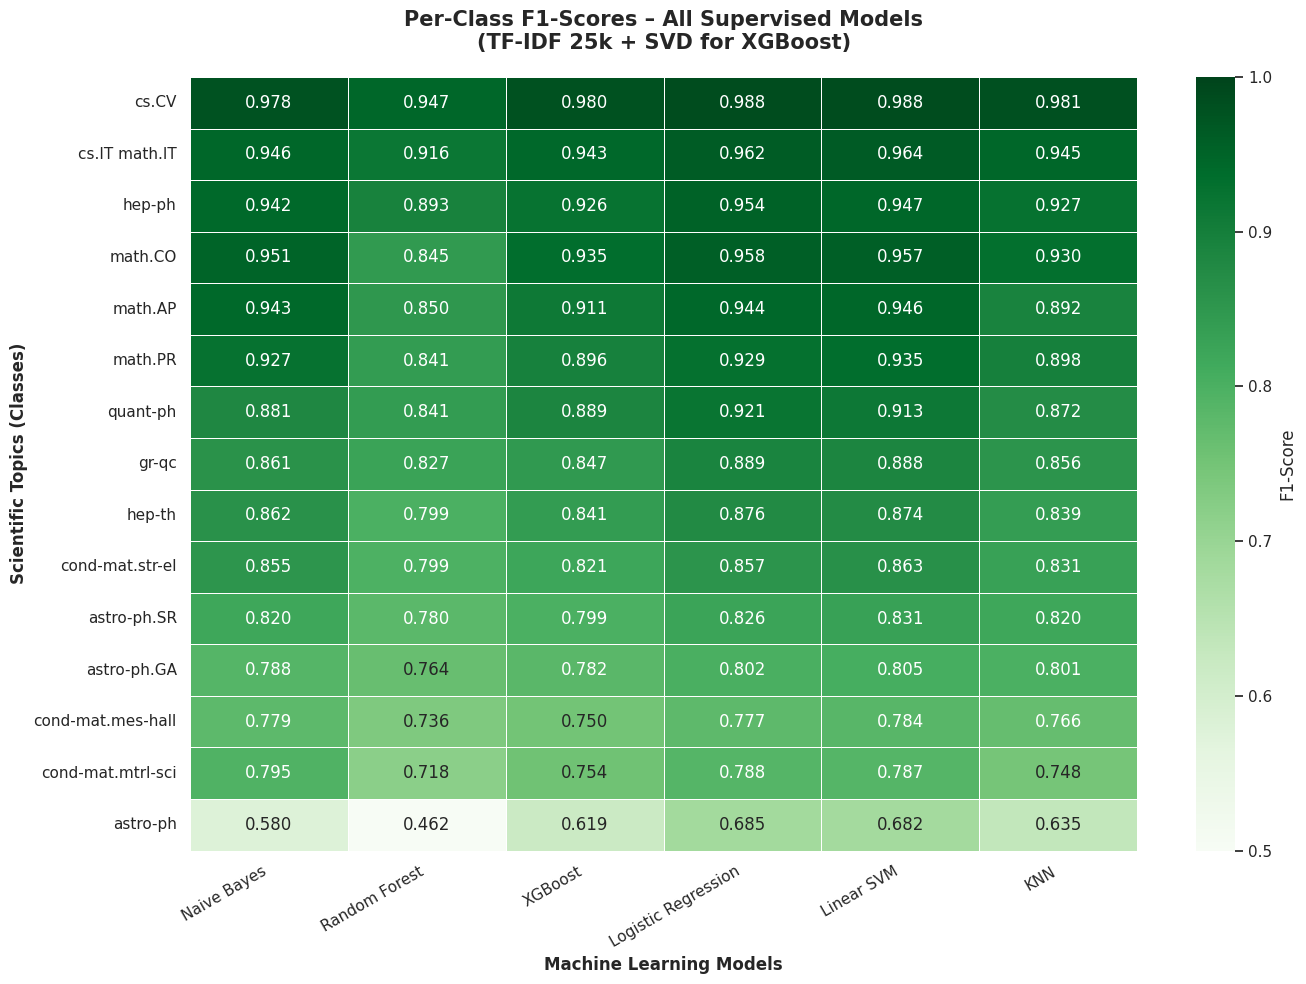

In [28]:
# ── CHART 6: Per-Class F1 Heatmap (All Supervised Models) ─────────────────
sns.set_theme(style="white")
predictions_all = {m: results[m]['y_pred'] for m in SUPERVISED_MODELS
                   if m in results}

f1_data = {}
for model_name, y_pred in predictions_all.items():
    report = classification_report(y_test_enc, y_pred,
                                   target_names=topic_names_real,
                                   output_dict=True)
    f1_data[model_name] = [report[t]['f1-score'] for t in topic_names_real]

df_f1 = pd.DataFrame(f1_data, index=topic_names_real)
df_f1['Average'] = df_f1.mean(axis=1)
df_f1 = df_f1.sort_values('Average', ascending=False).drop(columns=['Average'])

plt.figure(figsize=(14, 10))
sns.heatmap(df_f1, annot=True, cmap='Greens', fmt='.3f',
            linewidths=.5, cbar_kws={'label': 'F1-Score'},
            vmin=0.5, vmax=1.0)
plt.title('Per-Class F1-Scores – All Supervised Models\n(TF-IDF 25k + SVD for XGBoost)',
          fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Scientific Topics (Classes)', fontsize=12, fontweight='bold')
plt.xlabel('Machine Learning Models', fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()


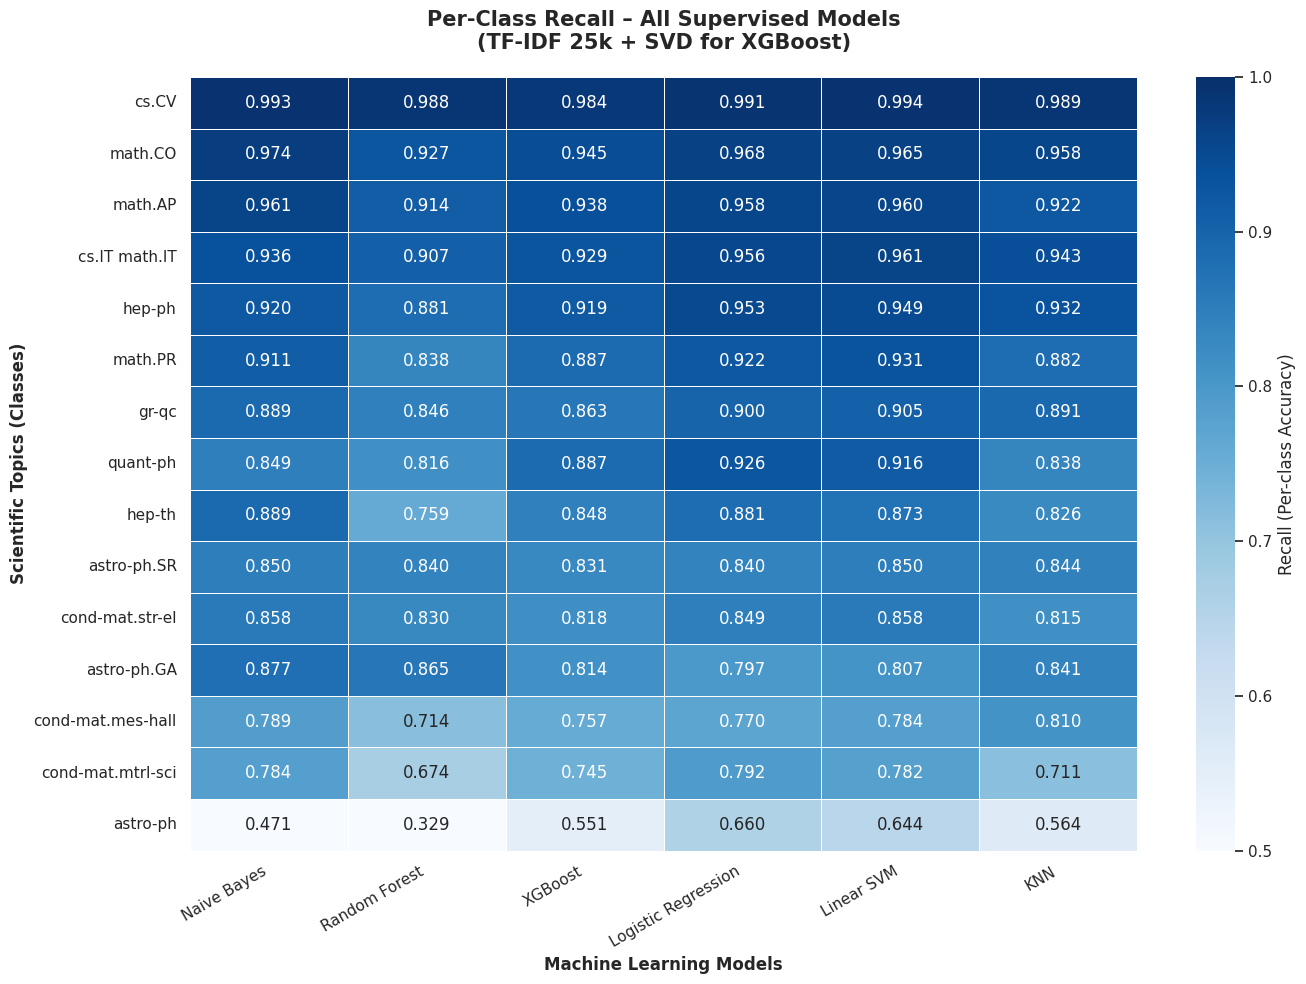

In [29]:
# ── CHART 7: Per-Class Recall Heatmap (All Supervised Models) ─────────────
recall_data = {}
for model_name, y_pred in predictions_all.items():
    report = classification_report(y_test_enc, y_pred,
                                   target_names=topic_names_real,
                                   output_dict=True)
    recall_data[model_name] = [report[t]['recall'] for t in topic_names_real]

df_recall = pd.DataFrame(recall_data, index=topic_names_real)
df_recall['Average'] = df_recall.mean(axis=1)
df_recall = df_recall.sort_values('Average', ascending=False).drop(columns=['Average'])

plt.figure(figsize=(14, 10))
sns.heatmap(df_recall, annot=True, cmap='Blues', fmt='.3f',
            linewidths=.5,
            cbar_kws={'label': 'Recall (Per-class Accuracy)'},
            vmin=0.5, vmax=1.0)
plt.title('Per-Class Recall – All Supervised Models\n(TF-IDF 25k + SVD for XGBoost)',
          fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Scientific Topics (Classes)', fontsize=12, fontweight='bold')
plt.xlabel('Machine Learning Models', fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

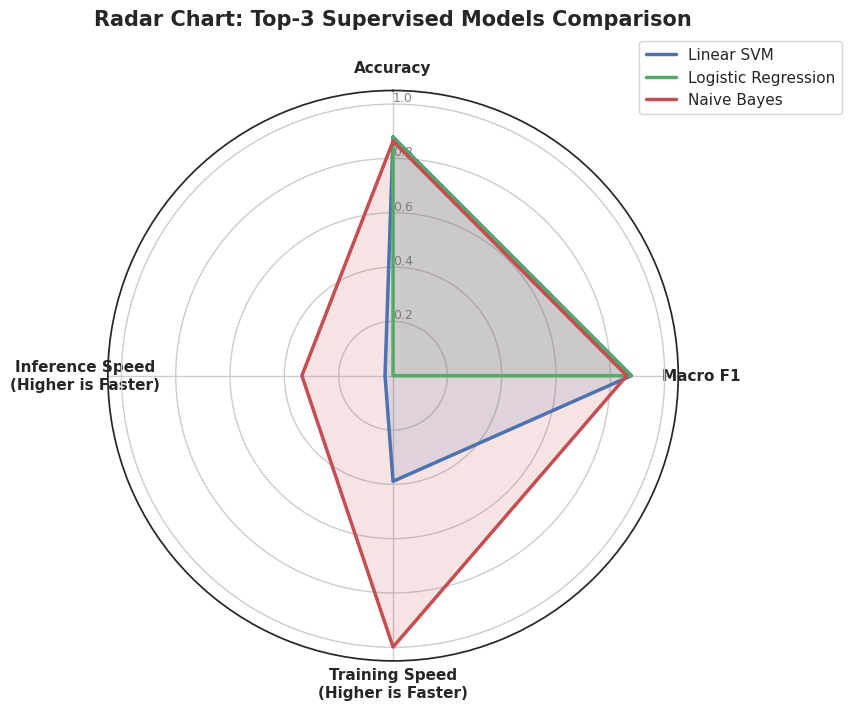

In [30]:
# ── CHART 8: Radar Chart (Top 3 Models by F1) ─────────────────────────────
from math import pi

top3 = sorted(SUPERVISED_MODELS,
              key=lambda m: results[m]['f1_macro'],
              reverse=True)[:3]

acc_r   = [results[m]['accuracy']   for m in top3]
f1_r    = [results[m]['f1_macro']   for m in top3]
t_times = [results[m]['train_time'] for m in top3]
i_times = [results[m]['infer_time'] for m in top3]

max_t = max(t_times)
max_i = max(i_times)
train_speed = [(max_t - t) / max_t for t in t_times]
infer_speed = [(max_i - t) / max_i for t in i_times]

metrics = [
    'Accuracy', 'Macro F1',
    'Training Speed\n(Higher is Faster)',
    'Inference Speed\n(Higher is Faster)'
]
N = len(metrics)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

data_radar = [
    [acc_r[i], f1_r[i], train_speed[i], infer_speed[i]]
    for i in range(len(top3))
]
radar_colors = ['#4C72B0', '#55A868', '#C44E52']

plt.figure(figsize=(9, 9))
ax = plt.subplot(111, polar=True)
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], metrics, fontsize=11, fontweight='bold')
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0],
           ["0.2", "0.4", "0.6", "0.8", "1.0"],
           color="grey", size=9)
plt.ylim(0, 1.05)

for i, (vals, color, name) in enumerate(zip(data_radar, radar_colors, top3)):
    v = vals + vals[:1]
    ax.plot(angles, v, color=color, linewidth=2.5, linestyle='solid', label=name)
    ax.fill(angles, v, color=color, alpha=0.15)

plt.title('Radar Chart: Top-3 Supervised Models Comparison',
          size=15, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.tight_layout()
plt.show()



In [31]:
print("\n[DONE] All sections completed successfully.")



[DONE] All sections completed successfully.
